Know that the goal of all the models are to fit into the function written on the title. The weights and biases' goal is to "become" the given function.

# 1.ANN Linear Regression for y = 5x + 20

<center><img src="https://drive.google.com/uc?export=view&id=1X2majxxpqhKuZzsCGFBNBZggqZAcnha_" alt = "Image show graph"></center>
<br>
- Hidden layer not necessary, since the function is simple and adding hidden layer/neuron will complicate the model for no reason

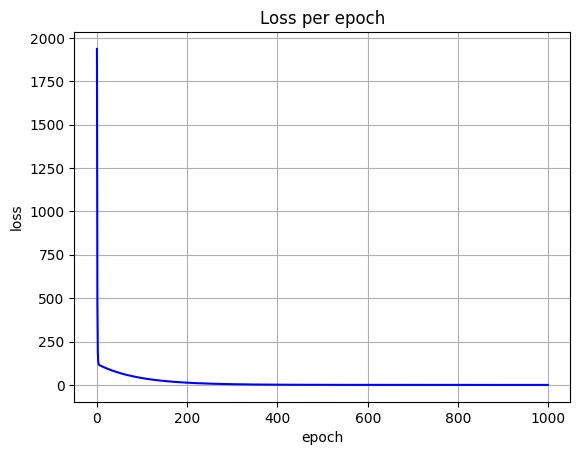

weight: 5
bias: 20
Output predicted by model : [290.5798485  355.73743798 225.42225901 496.07686149  85.0828355
 265.51923715 450.96776108 325.66470437 471.01625015  49.99797962]
Actual output : [290 355 225 495  85 265 450 325 470  50]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

class ANN1 :
  def __init__(self,input_size,output_size):
    self.error = 0
    self.input_size = input_size
    self.output_size = output_size

    # Randomly initialize weights and biases
    self.weights1 = np.random.randn(self.input_size, self.output_size)
    self.biases1 = np.random.randn(self.output_size)

  def forward(self, x1):
    self.output_layer = self.weights1 * x1 + self.biases1

  def backward(self, x_train, y_train, learning_rate):
    output_error = self.output_layer - y_train
    self.error = output_error

    output_delta = np.mean((output_error)**2)

    weight_gradient = 2 * np.mean(output_error * x_train)
    bias_gradient = 2 * np.mean(output_error)

    self.weights1 -= learning_rate * weight_gradient
    self.biases1 -= learning_rate * bias_gradient

  def train(self, x_train, y_train,learning_rate, epochs):
    loss_value = []
    for epoch in range(epochs):
      self.forward(x_train)
      self.backward(x_train, y_train, learning_rate)
      loss = np.mean((self.error)**2)
      loss_value.append(loss)
    plt.plot(loss_value, 'b')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('Loss per epoch')
    plt.grid(True)
    plt.show()
    loss_value = np.array(loss_value)
    print(f'weight: {round(self.weights1.item())}')
    print(f'bias: {round(self.biases1.item())}')

  def predict(self, x_test):
    self.forward(x_test)
    return self.output_layer


x_train = np.random.randint(10, size=100)
y_train = 5 * x_train + 20

ANN1 = ANN1(input_size=1, output_size=1)
ANN1.train(x_train, y_train, learning_rate=0.01, epochs=1000)

x_test = np.array(np.random.randint(100,size=100))
y_test = ANN1.predict(x_test)
print(f'Output predicted by model : {y_test[0][:10]}')

y = lambda x:5*x+20
print(f'Actual output : {y(x_test[:10])}')

# 2.ANN Polynommial Regression for y = 5x^2 + 10x + 20


## Straightforward version

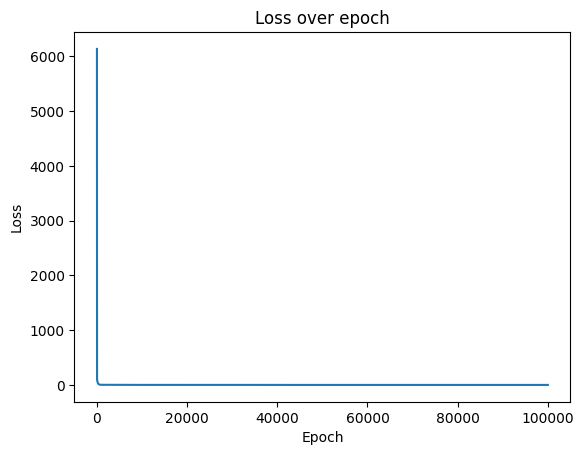

Final weights:
w1 = 4.999951766548912
w2 = 10.000425858359243
w3 = 19.999226080906247


In [ ]:
import matplotlib.pyplot as plt
# Define the input data
x_train = [1, 2, 3, 4, 5, 6, 7]
y_train = [5*x**2 + 10*x+20 for x in x_train] # y = 5x^2 + 10x + 20

# Initialize the weights
w1 = 3.0
w2 = 6.0
w3 = 9.0

# Set the learning rate and number of iterations
learning_rate = 0.001
num_iterations = 100000

error = []
# Training loop
for i in range(num_iterations):
    # Forward propagation
    y_pred = [w1 * x**2 + w2 * x + w3 for x in x_train]

    # Calculate the loss (mean squared error)
    loss = sum((y_pred[i] - y_train[i])**2 for i in range(len(y_train))) / len(y_train)
    error.append(loss)

    # Calculate the gradients for the weights
    grad_w1 = sum(2 * (y_pred[i] - y_train[i]) * x_train[i]**2 for i in range(len(x_train))) / len(x_train)
    grad_w2 = sum(2 * (y_pred[i] - y_train[i]) * x_train[i] for i in range(len(x_train))) / len(x_train)
    grad_w3 = sum(2 * (y_pred[i] - y_train[i]) for i in range(len(y_train))) / len(y_train)

    # Update the weights using gradient descent
    w1 -= learning_rate * grad_w1
    w2 -= learning_rate * grad_w2
    w3 -= learning_rate * grad_w3

plt.title('Loss over epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.plot(error)
plt.show()

# Print the final weights
print("Final weights:")
print("w1 =", w1)
print("w2 =", w2)
print("w3 =", w3)

## Class model version

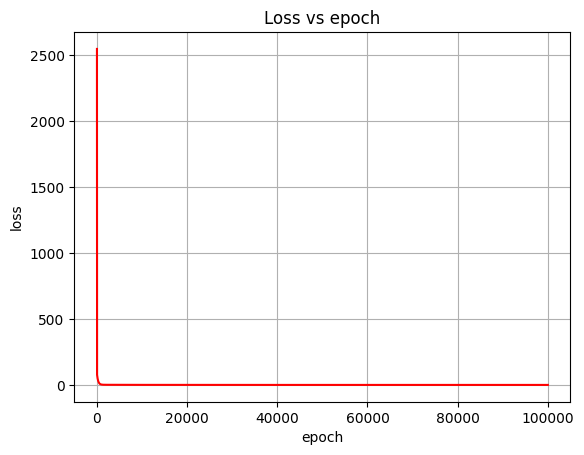

Weight1 : 4.997769103031339
Weight2 : 10.014393507156434
Weight3 : 19.980821751747754
Output predicted by model : [22.183611217300296, 39.1948814687006, 66.2016899261636, 103.20403658968927, 150.2019214592776]
Actual output : [22.2, 39.2, 66.2, 103.20000000000002, 150.2]


In [ ]:
import matplotlib.pyplot as plt
class polyann:
  def __init__(self,input_size, output_size):
    self.error = []
    self.input_size = input_size
    self.output_size = output_size

    self.weight1 = 3.0
    self.weight2 = 6.0
    self.weight3 = 9.0

  def forward(self,x):
    self.output_layer = [self.weight1* i**2 + self.weight2*i + self.weight3 for i in x]

  def backward(self,x,y,learning_rate):
    # loss
    loss =  sum((self.output_layer[i] - y[i])**2 for i in range(len(y)))/len(y)
    self.error.append(loss)

    # gradient
    dw1 = sum(2*(self.output_layer[i]-y[i])*x[i]**2 for i in range(len(x)))/len(x)
    dw2 = sum(2*(self.output_layer[i]-y[i])*x[i] for i in range(len(x)))/len(x)
    dw3 = sum(2*(self.output_layer[i]-y[i]) for i in range(len(x)))/len(x)

    # update
    self.weight1 -= dw1 * learning_rate
    self.weight2 -= dw2 * learning_rate
    self.weight3 -= dw3 * learning_rate

  def train(self, x, y, learning_rate, epochs):
    for epoch in range(epochs):
      self.forward(x)
      self.backward(x,y,learning_rate)

    plt.plot(self.error, 'r')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('Loss vs epoch')
    plt.grid(True)
    plt.show()

    print(f'Weight1 : {self.weight1}')
    print(f'Weight2 : {self.weight2}')
    print(f'Weight3 : {self.weight3}')

  def predict(self, x):
    self.forward(x)
    return self.output_layer

x_train = [x+1 for x in range(5)]
y_train = [5*x**2 + 10*x + 20 for x in x_train]

lr = 0.001
epochs = 100000

polyann = polyann(input_size=1,output_size=1)
polyann.train(x_train,y_train,lr,epochs)

x_test = [x+0.2 for x in range(5)]
y_test = polyann.predict(x_test)
print(f'Output predicted by model : {y_test[:10]}')


y = [5*x**2 + 10*x + 20 for x in x_test]
print(f'Actual output : {y[:10]}')

# 3.ANN model for y = 5 x^5 + 10 x^3 + 20 x^2 + 35

With complex polynomial equations, the ways shown above quickly become unreliable unless one decided to derive all those increasing powers on their own.

Let's introduce activation function and generalised functions for doing the same task

## Linear method will fail

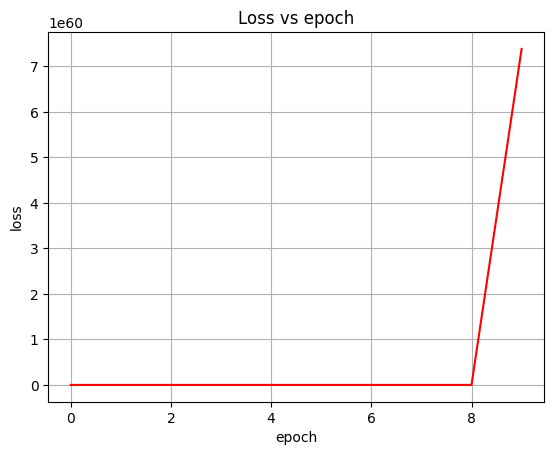

Weight1 : -7.976471569785332e+30
Weight2 : -3.455642978365563e+29
Weight3 : -7.32305147269634e+28
Weight4 : -3.4970375924302597e+27
Output predicted by model : [-2.1953127075857785e+28, -1.7246095532567687e+31, -1.9089113377739786e+32, -8.484704936958275e+32, -2.5089329187969653e+33]
Actual output : [35.8816, 93.52159999999999, 495.96160000000015, 2245.2016000000003, 7663.241600000002]


In [ ]:
import matplotlib.pyplot as plt
class polyann:
  def __init__(self,input_size, output_size):
    self.error = []
    self.input_size = input_size
    self.output_size = output_size

    self.weight1 = 3.0
    self.weight2 = 6.0
    self.weight3 = 9.0
    self.weight4 = 0.0

  def forward(self,x):
    self.output_layer = [self.weight1* i**4+self.weight2*i**3 + self.weight3*i**2 + self.weight4 for i in x]

  def backward(self,x,y,learning_rate):
    # loss
    loss =  sum((self.output_layer[i] - y[i])**2 for i in range(len(y)))/len(y)
    self.error.append(loss)

    # gradient
    dw1 = sum(2*(self.output_layer[i]-y[i])*x[i]**5 for i in range(len(x)))/len(x)
    dw2 = sum(2*(self.output_layer[i]-y[i])*x[i]**3 for i in range(len(x)))/len(x)
    dw3 = sum(2*(self.output_layer[i]-y[i])*x[i]**2 for i in range(len(x)))/len(x)
    dw4 = sum(2*(self.output_layer[i]-y[i]) for i in range(len(x)))/len(x)

    # update
    self.weight1 -= dw1 * learning_rate
    self.weight2 -= dw2 * learning_rate
    self.weight3 -= dw3 * learning_rate
    self.weight4 -= dw4 * learning_rate

  def train(self, x, y, learning_rate, epochs):
    for epoch in range(epochs):
      self.forward(x)
      self.backward(x,y,learning_rate)

    plt.plot(self.error, 'r')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('Loss vs epoch')
    plt.grid(True)
    plt.show()

    print(f'Weight1 : {self.weight1}')
    print(f'Weight2 : {self.weight2}')
    print(f'Weight3 : {self.weight3}')
    print(f'Weight4 : {self.weight4}')

  def predict(self, x):
    self.forward(x)
    return self.output_layer

x_train = [x+1 for x in range(5)]
y_train = [5*x**5 + 10*x**3 + 20*x**2 + 35 for x in x_train]

lr = 0.001
epochs = 10

polyann = polyann(input_size=1,output_size=1)
polyann.train(x_train,y_train,lr,epochs)

x_test = [x+0.2 for x in range(5)]
y_test = polyann.predict(x_test)
print(f'Output predicted by model : {y_test[:10]}')


y = [5*x**5 + 10*x**3 + 20*x**2 + 35 for x in x_test]
print(f'Actual output : {y[:10]}')

## Straightforward version (Polynomial)

In [ ]:
import numpy as np

# Generate some synthetic data
np.random.seed(0)
X = np.random.rand(100, 1) * 2 - 1  # Random values between -1 and 1
y = 5 * X**5 + 10 * X**3 + 20 * X**2 + 35 + np.random.randn(100, 1) * 0.1  # Adding noise

# Define the neural network architecture
input_size = 1
hidden_size = 10
output_size = 1
learning_rate = 0.01
epochs = 1000

# Initialize weights and biases
weights_input_hidden = np.random.randn(input_size, hidden_size)
bias_hidden = np.zeros((1, hidden_size))
weights_hidden_output = np.random.randn(hidden_size, output_size)
bias_output = np.zeros((1, output_size))

# Training the neural network
for epoch in range(epochs):
    # Forward pass
    hidden_layer_input = np.dot(X, weights_input_hidden) + bias_hidden
    hidden_layer_output = 1 / (1 + np.exp(-hidden_layer_input))  # Sigmoid activation
    output_layer_input = np.dot(hidden_layer_output, weights_hidden_output) + bias_output
    predicted_output = output_layer_input

    # Compute loss
    loss = np.mean((predicted_output - y)**2)

    # Backpropagation
    dloss = 2 * (predicted_output - y) / len(X)
    doutput = dloss
    dweights_hidden_output = np.dot(hidden_layer_output.T, doutput)
    dbias_output = np.sum(doutput, axis=0, keepdims=True)
    dhidden = np.dot(doutput, weights_hidden_output.T) * hidden_layer_output * (1 - hidden_layer_output)
    dweights_input_hidden = np.dot(X.T, dhidden)
    dbias_hidden = np.sum(dhidden, axis=0, keepdims=True)

    # Update weights and biases using gradient descent
    weights_input_hidden -= learning_rate * dweights_input_hidden
    bias_hidden -= learning_rate * dbias_hidden
    weights_hidden_output -= learning_rate * dweights_hidden_output
    bias_output -= learning_rate * dbias_output

    # Print the loss every 100 epochs
    if epoch % 100 == 0:
        print(f'Epoch {epoch}: Loss = {loss:.4f}')

# Evaluate the trained model
def predict(x):
    hidden_layer_input = np.dot(x, weights_input_hidden) + bias_hidden
    hidden_layer_output = 1 / (1 + np.exp(-hidden_layer_input))
    output_layer_input = np.dot(hidden_layer_output, weights_hidden_output) + bias_output
    return output_layer_input

x_test = np.array([[0.5]])  # Test with a single input value
predicted_y = predict(x_test)
print(f'Predicted y for x = {x_test[0, 0]}: {predicted_y[0, 0]}')
print(f'Actual y for x = {x_test[0, 0]}: {[5*x_test[0,0]**5 + 10*x_test[0,0]**3 + 20*x_test[0,0]**2 + 35][0]}')


## Class model version

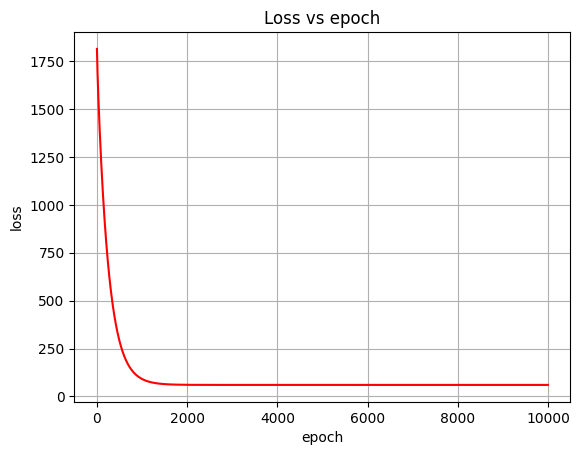

Weight1 : [[-30.56498064]]
Biases1 : [[-29.07835449]]
Weight2 : [[-0.69805585]]
Biases2 : [[41.198105]]
Predicted y for x = 0.5: 41.19810500309927
Actual y for x = 0.5: 41.40625


In [2]:
import numpy as np
import matplotlib.pyplot as plt
def sigmoid(x):
  return 1/(1+np.exp(-x))

def sigmoid_der(x):
  return sigmoid(x) + (1-sigmoid(x))

class ann:
  def __init__(self, input_size, hidden_size, output_size):
    self.error = []
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.output_size = output_size

    self.weights1 = np.random.randn(input_size, hidden_size) # weight hidden input
    self.biases1 = np.zeros((1,hidden_size))
    self.weights2 = np.random.randn(hidden_size, output_size) # weight hidden output
    self.biases2 = np.zeros((1,output_size))

  def forward(self, x):
    self.hidden_layer = sigmoid(np.dot(x,self.weights1) + self.biases1) # hidden layer input, output
    self.output_layer = np.dot(self.hidden_layer,self.weights2) + self.biases2 # output layer input, no activation output


  def backward(self, x, y, lr):
    # loss
    loss =  np.mean((self.output_layer - y)**2)
    self.error.append(loss)

    dloss = 2 * (self.output_layer - y) / len(x)
    doutput = dloss

    dw2 = np.dot(self.hidden_layer.T, doutput)
    db2 = np.sum(doutput, axis=0, keepdims=True)
    #dhidden = np.dot(doutput, self.weights2.T)*self.hidden_layer * (1-self.hidden_layer)
    dhidden = np.dot(doutput,self.weights2.T)*sigmoid_der(self.hidden_layer)
    dw1 = np.dot(x.T, dhidden)
    db1 = np.sum(dhidden, axis=0, keepdims=True)

    self.weights1 -= lr*dw1
    self.biases1 -= lr*db1
    self.weights2 -= lr*dw2
    self.biases2 -= lr*db2


  def train(self, x, y , lr, epochs):
    for epoch in range(epochs):
      self.forward(x)
      self.backward(x, y, lr)

    plt.plot(self.error, 'r')
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('Loss vs epoch')
    plt.grid(True)
    plt.show()

    print(f'Weight1 : {self.weights1}')
    print(f'Biases1 : {self.biases1}')
    print(f'Weight2 : {self.weights2}')
    print(f'Biases2 : {self.biases2}')

  def predict(self, x):
    self.forward(x)
    return self.output_layer

input_size = 1
hidden_size = 1
output_size = 1
lr = 0.001
epochs = 10000

np.random.seed(0)
x_train = np.random.rand(100, 1) * 2 - 1  # Random values between -1 and 1
y_train = 5 * x_train**5 + 10 * x_train**3 + 20 * x_train**2 + 35 + np.random.randn(100, 1) * 0.1  # Adding noise

ann = ann(input_size = input_size, hidden_size = hidden_size, output_size = output_size)
ann.train(x_train, y_train, lr, epochs)

x_test = np.array([[0.5]])
y_test = ann.predict(x_test)
print(f'Predicted y for x = {x_test[0,0]}: {y_test[0,0]}')
print(f'Actual y for x = {x_test[0,0]}: {(5*x_test**5 + 10*x_test**3 +20*x_test**2 +35)[0,0]}')

# 4.Drawing activation function graphs

[-50, -49, -48, -47, -46, -45, -44, -43, -42, -41, -40, -39, -38, -37, -36, -35, -34, -33, -32, -31, -30, -29, -28, -27, -26, -25, -24, -23, -22, -21, -20, -19, -18, -17, -16, -15, -14, -13, -12, -11, -10, -9, -8, -7, -6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]
[-5.0, -4.9, -4.800000000000001, -4.7, -4.6000000000000005, -4.5, -4.4, -4.3, -4.2, -4.1000000000000005, -4.0, -3.9000000000000004, -3.8000000000000003, -3.7, -3.6, -3.5, -3.4000000000000004, -3.3000000000000003, -3.2, -3.1, -3.0, -2.9000000000000004, -2.8000000000000003, -2.7, -2.6, -2.5, -2.4000000000000004, -2.3000000000000003, -2.2, -2.1, -2.0, -1.9000000000000001, -1.8, -1.7000000000000002, -1.6, -1.5, -1.4000000000000001, -1.3, -1.2000000000000002, -1.1, -1.0, -0.9, -0.8, -0.7000000000000001, -0.6000000000000001, -0.5, -0.4, -0.30000000000000004, -0.2, -0.

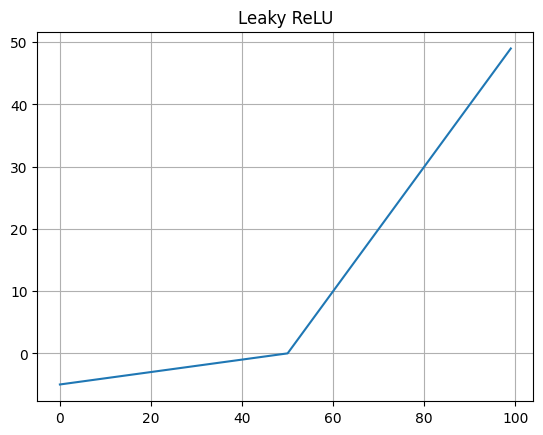

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


data = [x for x in np.arange(-50,50)]
print(data)

def linear(x):
  return x

def linear_der(x):
  return 1

def step(x):
  return 1 if x >=0 else 0

def step_der(x):
  return np.where(x == 0, np.nan, 0)

def sigmoid(x):
  return 1/(1+np.exp(-x))

def sigmoid_der(x):
  return sigmoid(x) * (1 - sigmoid(x))

def tanh(x):
  return np.tanh(x)

def tanh_der(x):
  return 1 - np.tanh(x)

def relu(x):
  return max(0,x)

def relu_der(x):
  return 1 if x > 0 else 0

def leaky_relu(x, a):
  return x if x > 0 else x*a

def leaky_relu_der(x,a):
  return 1 if x > 0 else a

"""
Here onwards, input are in numpy array form, same stuff
"""

# LeCun normalisation for tanh and relu
def lecun_init(x, activation = 'tanh'):
  if activation == 'tanh':
    sigma = np.sqrt(1.0 / x)
  elif activation == 'relu':
    sigma = np.sqrt(2.0 / x)
  else:
    raise ValueError("Unsupported activation function")

  return np.random.normal(0, sigma, size=(x,))

# Commonly used layer normalisation (good practice to do this)
def batch_normalisation(x):
  mean = np.mean(x,axis=0)
  std = np.std(x,axis=0)
  normalised_x = (x-mean)/(std + 1e-8) # avoid minus 0 (numeric stability)
  return normalised_x

def layer_normalisation(x):
  mean = np.mean(x, axis=1, keepdims=True)
  std = np.mean(x, axis=1, keepdims=True)
  normalised_x = (x - mean)/(std + 1e-8)
  return normalised_x

# y = [linear(i) for i in data]
# plt.title("Linear")
# y = [step(i) for i in data]
# plt.title("Step")
# y = [sigmoid(i) for i in data]
# plt.title("Sigmoid")
# y = [tanh(i) for i in data]
# plt.title("Tanh")
# y = [relu(i) for i in data]
# plt.title("ReLU")
y = [leaky_relu(i, 0.1) for i in data]
plt.title("Leaky ReLU")

def elu(x, alpha=1.6733):
  return np.where(x > 0, x, alpha * (np.exp(x) - 1)) # np.where for numpy array

def elu_der(x, alpha=1.6733):
  return np.where(x > 0, 1, np.exp(x) + alpha)

def selu (x, alpha = 1.6733, scale=1.0507):
  # return scale * x if x > 0 else scale * (alpha * (np.exp(x) - 1))
  return scale * np.where(x >= 0, x, alpha * (np.exp(x) - 1)) # np.where for numpy array

def selu_der(x, alpha = 1.6733, scale=1.0507):
  return scale * np.where(x > 0, 1, alpha * np.exp(x))

# selu specific functions
# data = np.array(data)
# data = batch_normalisation(data) # LeCun initialisation
# y = selu(data)

# y = elu(data)

print(y)
plt.grid(True)
plt.plot(y)

In [ ]:
""""
PReLU simple implementation
"""
import numpy as np

class PReLU:

  def __init__ (self, input_shape, alpha_init=0.25):
    # basically initiate a numpy array / tensor filled with alpha_init, the size of input_size
    self.alpha = np.full(input_shape,alpha_init, dtype=np.float32)
    self.input_shape = input_shape


  def forward(self, x):
    # return x if x>0 else x*alpha
    return np.where(x > 0, x, x*self.alpha)

  def update_alpha(self, delta_alpha):
    self.alpha -= delta_alpha


input_shape = (3,3)
prelu_layer = PReLU(input_shape)
x = np.array([[-1.0, 0.0, 1.0], [2.0, -2.0, 3.0], [-3.0, 3.0, -3.0]])

output = prelu_layer.forward(x)
print(output)

# post backpropagation, update the weights
delta_alpha = np.array([[0.1, 0.2, 0.3], [0.2, 0.1, 0.2], [0.3, 0.3, 0.3]])
prelu_layer.update_alpha(delta_alpha)
print("Updated 'alpha' parameter/weight:")
print(prelu_layer.alpha)

[[-0.25  0.    1.  ]
 [ 2.   -0.5   3.  ]
 [-0.75  3.   -0.75]]
Updated 'alpha' parameter:
[[ 0.15  0.05 -0.05]
 [ 0.05  0.15  0.05]
 [-0.05 -0.05 -0.05]]


# 5.Trigonometric function gradient descent for y = cos (x) (1 in, 1 hidden, 1 out)

##Straightforward with tanh activation function

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
x = np.linspace(-2*np.pi, 2 * np.pi, 10).reshape(-1, 1)
y = np.cos(x)
# Define the architecture of the neural network
input_size = 1
hidden_size = 10
output_size = 1
learning_rate = 0.01
epochs = 10000

# Initialize weights and biases
weight_input_hidden = np.random.randn(input_size, hidden_size)
bias_hidden = np.zeros((1, hidden_size))
weight_hidden_output = np.random.randn(hidden_size, output_size)
bias_output = np.zeros((1, output_size))

# Training loop
for epoch in range(epochs):
    # Forward pass
    # hidden layer
    hidden_layer_input = np.dot(x, weight_input_hidden) + bias_hidden #hidden_layer_input
    hidden_layer_output = np.tanh(hidden_layer_input) #a1

    # layer output
    output_layer_input = np.dot(hidden_layer_output, weight_hidden_output) + bias_output #z2
    output_layer_output = output_layer_input #a2

    # Compute loss
    loss = np.mean((output_layer_output - y)**2)

    # Backpropagation
    grad_output_layer_output = 2 * (output_layer_output - y)
    grad_output_layer_input = grad_output_layer_output
    grad_weight_hidden_output = np.dot(hidden_layer_output.T, grad_output_layer_input)
    grad_bias_output = np.sum(grad_output_layer_input, axis=0, keepdims=True)
    grad_hidden_layer_output = np.dot(grad_output_layer_input, weight_hidden_output.T)
    grad_hidden_layer_input = grad_hidden_layer_output * (1 - np.tanh(hidden_layer_input)**2)
    grad_weight_input_hidden = np.dot(x.T, grad_hidden_layer_input)
    grad_bias_hidden = np.sum(grad_hidden_layer_input, axis=0, keepdims=True)

    # Update weights and biases
    weight_input_hidden -= learning_rate * grad_weight_input_hidden
    bias_hidden -= learning_rate * grad_bias_hidden
    weight_hidden_output -= learning_rate * grad_weight_hidden_output
    bias_output -= learning_rate * grad_bias_output

    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{epochs}], Loss: {loss:.4f}")

# Predictions
hidden_layer_input = np.dot(x, weight_input_hidden) + bias_hidden
hidden_layer_output = np.tanh(hidden_layer_input)
output_layer_input = np.dot(hidden_layer_output, weight_hidden_output) + bias_output
predictions = output_layer_input

# Plot the results
plt.scatter(x, y, label='Actual Data', s=5)
plt.plot(x, predictions, label='Predictions', color='red', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

Equal but different representation

Epoch [0/10000], Loss: 9.0667
Epoch [1000/10000], Loss: 0.1569
Epoch [2000/10000], Loss: 0.0185
Epoch [3000/10000], Loss: 0.0027
Epoch [4000/10000], Loss: 0.0004
Epoch [5000/10000], Loss: 0.0001
Epoch [6000/10000], Loss: 0.0000
Epoch [7000/10000], Loss: 0.0000
Epoch [8000/10000], Loss: 0.0000
Epoch [9000/10000], Loss: 0.0000


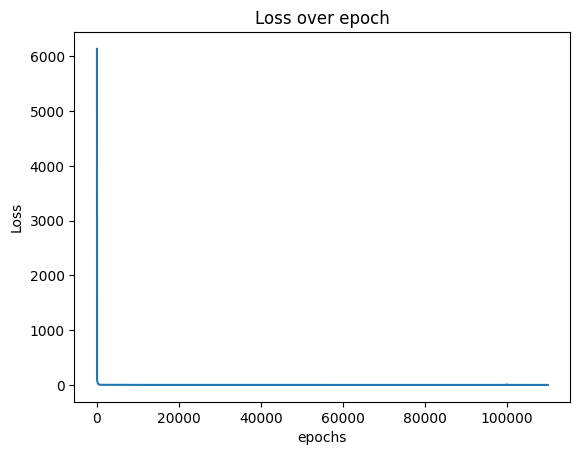

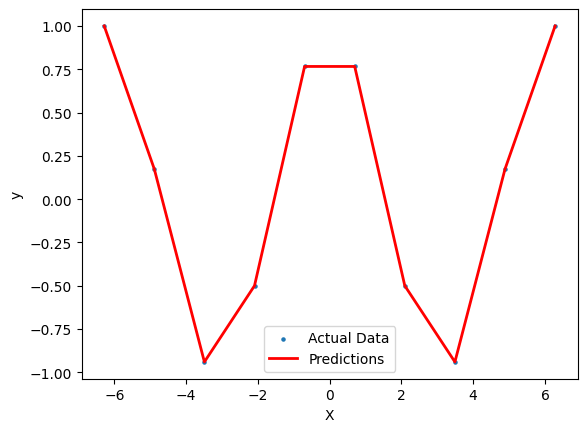

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
X = np.linspace(-2*np.pi, 2 * np.pi, 10).reshape(-1, 1)
y = np.cos(X)
# Define the architecture of the neural network
input_size = 1
hidden_size = 10
output_size = 1
learning_rate = 0.01
num_epochs = 10000
loss = []

# Initialize weights and biases
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

# Training loop
for epoch in range(num_epochs):
    # Forward pass
    z1 = np.dot(X, W1) + b1
    a1 = np.tanh(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = z2

    # Compute loss
    loss = np.mean((a2 - y)**2)
    error.append(loss)

    # Backpropagation
    grad_a2 = 2 * (a2 - y)
    grad_z2 = grad_a2
    grad_W2 = np.dot(a1.T, grad_z2)
    grad_b2 = np.sum(grad_z2, axis=0, keepdims=True)
    grad_a1 = np.dot(grad_z2, W2.T)
    grad_z1 = grad_a1 * (1 - np.tanh(z1)**2)
    grad_W1 = np.dot(X.T, grad_z1)
    grad_b1 = np.sum(grad_z1, axis=0, keepdims=True)

    # Update weights and biases
    W1 -= learning_rate * grad_W1
    b1 -= learning_rate * grad_b1
    W2 -= learning_rate * grad_W2
    b2 -= learning_rate * grad_b2

    if epoch % 1000 == 0:
        print(f"Epoch [{epoch}/{num_epochs}], Loss: {loss:.4f}")

# Predictions
z1 = np.dot(X, W1) + b1
a1 = np.tanh(z1)
z2 = np.dot(a1, W2) + b2
predictions = z2

# Plot the results
plt.plot(error)
plt.title('Loss over epoch')
plt.xlabel('epochs')
plt.ylabel('Loss')
plt.show()

plt.scatter(X, y, label='Actual Data', s=5)
plt.plot(X, predictions, label='Predictions', color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

#6.Effect of Hidden layers, Activation functions; Trigonometric and Polynomial function for y = 2 cos2 (3x) + 30 sin(2x2)

##With tanh activation function

Epoch [0/1000], Loss: 19.6664
Epoch [100/1000], Loss: 16.0206
Epoch [200/1000], Loss: 15.6759
Epoch [300/1000], Loss: 15.4317
Epoch [400/1000], Loss: 15.2082
Epoch [500/1000], Loss: 15.0930
Epoch [600/1000], Loss: 14.8789
Epoch [700/1000], Loss: 14.7508
Epoch [800/1000], Loss: 14.6422
Epoch [900/1000], Loss: 14.5473


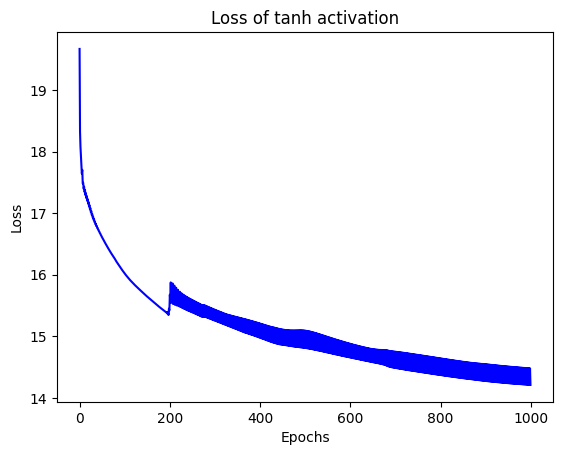

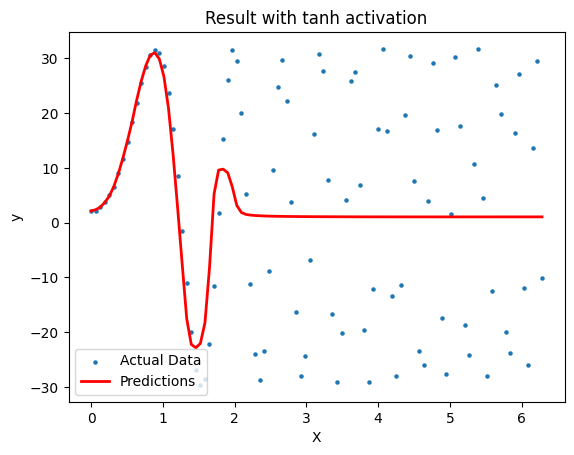

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data
np.random.seed(0)
X = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)
y = 2 * np.cos(3 * X)**2 + 30 * np.sin(2 * X**2) + np.random.normal(0, 0.1, X.shape)

# Define the neural network architecture
input_size = 1
hidden_size = 64
output_size = 1
learning_rate = 0.01
num_epochs = 1000
error = []

# Initialize weights and biases
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, hidden_size)
b2 = np.zeros((1, hidden_size))
W3 = np.random.randn(hidden_size, output_size)
b3 = np.zeros((1, output_size))

# Training loop
for epoch in range(num_epochs):
    # Forward pass
    z1 = np.dot(X, W1) + b1
    a1 = np.tanh(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = np.tanh(z2)
    z3 = np.dot(a2, W3) + b3
    predictions = z3

    # Compute loss
    loss = np.mean(np.abs(predictions - y))
    error.append(loss)

    # Backpropagation
    dloss = (predictions - y) / len(X)
    dz3 = dloss
    dW3 = np.dot(a2.T, dz3)
    db3 = np.sum(dz3, axis=0, keepdims=True)
    da2 = np.dot(dz3, W3.T)
    dz2 = da2 * (1 - np.tanh(z2)**2)  # Use the derivative here
    dW2 = np.dot(a1.T, dz2)
    db2 = np.sum(dz2, axis=0, keepdims=True)
    da1 = np.dot(dz2, W2.T)
    dz1 = da1 * (1 - np.tanh(z1)**2)  # Use the derivative here
    dW1 = np.dot(X.T, dz1)
    db1 = np.sum(dz1, axis=0, keepdims=True)

    # Update weights and biases using gradient descent
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

    if epoch % 100 == 0:
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss:.4f}')

# Predictions
z1 = np.dot(X, W1) + b1
a1 = np.tanh(z1)
z2 = np.dot(a1, W2) + b2
a2 = np.tanh(z2)
z3 = np.dot(a2, W3) + b3
predictions = z3

# Plot the results
plt.title('Loss of tanh activation')
plt.plot(error, 'b')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

plt.title('Result with tanh activation')
plt.scatter(X, y, label='Actual Data', s=5)
plt.plot(X, predictions, label='Predictions', color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()


4/4 [==============================] - 0s 3ms/step


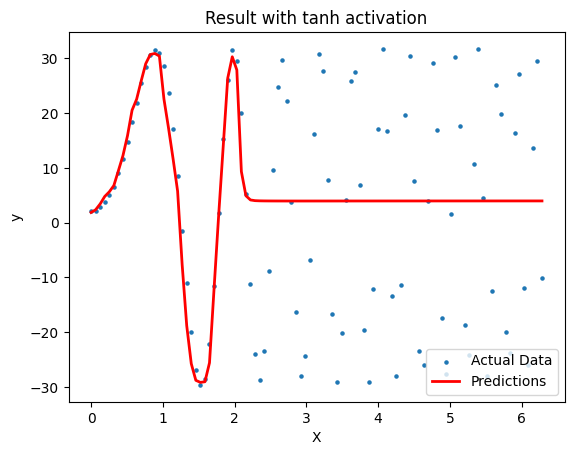

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, LeakyReLU, ReLU
from keras.optimizers import SGD

# Generate synthetic data
np.random.seed(0)
X = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)
y = 2 * np.cos(3 * X)**2 + 30 * np.sin(2 * X**2) + np.random.normal(0, 0.1, X.shape)

# Create a Keras sequential model
model = Sequential()

# Add a dense (fully connected) hidden layer with Leaky ReLU activation
model.add(Dense(64, input_dim=1, activation='tanh'))

# Add another hidden layer
model.add(Dense(64, activation='tanh'))
# Add the output layer with one neuron (regression problem)
model.add(Dense(1))

# Compile the model with Mean Absolute Error (MAE) loss and Adam optimizer
model.compile(loss='mae', optimizer=SGD(learning_rate=0.01))

# Train the model
history = model.fit(X, y, epochs=1000, batch_size=1, verbose=0)

# Predictions
predictions = model.predict(X)

# Plot the results
plt.title('Result with tanh activation')
plt.scatter(X, y, label='Actual Data', s=5)
plt.plot(X, predictions, label='Predictions', color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

##With ReLU

4/4 [==============================] - 0s 2ms/step


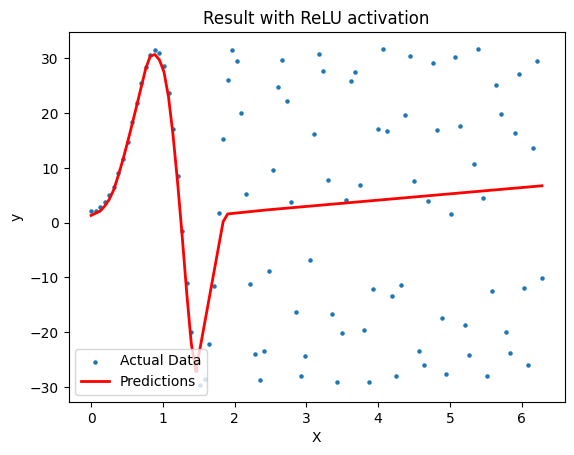

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, LeakyReLU, ReLU
from keras.optimizers import Adam, SGD

# Generate synthetic data
np.random.seed(0)
X = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)
y = 2 * np.cos(3 * X)**2 + 30 * np.sin(2 * X**2) + np.random.normal(0, 0.1, X.shape)

# Create a Keras sequential model
model = Sequential()

# Add a dense (fully connected) hidden layer with Leaky ReLU activation
model.add(Dense(64, input_dim=1))
model.add(ReLU())

# Add another hidden layer
model.add(Dense(64))
model.add(ReLU())

# Add the output layer with one neuron (regression problem)
model.add(Dense(1))

# Compile the model with Mean Absolute Error (MAE) loss and Adam optimizer
model.compile(loss='mae', optimizer=Adam(learning_rate=0.01))

# Train the model
history = model.fit(X, y, epochs=1000, batch_size=32, verbose=0)

# Predictions
predictions = model.predict(X)

# Plot the results
plt.title('Result with ReLU activation')
plt.scatter(X, y, label='Actual Data', s=5)
plt.plot(X, predictions, label='Predictions', color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

##With Leaky ReLU

4/4 [==============================] - 0s 3ms/step


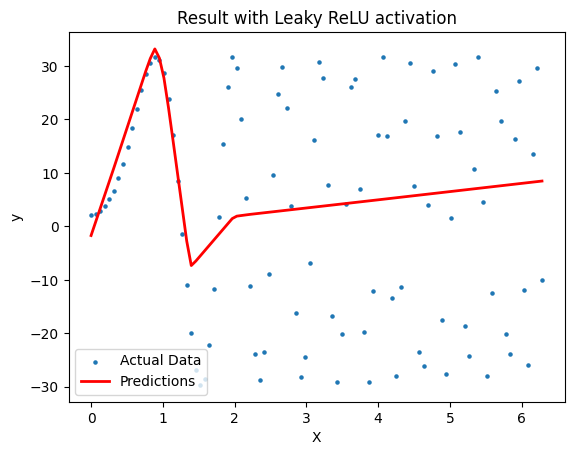

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, LeakyReLU, ReLU
from keras.optimizers import Adam, SGD

# Generate synthetic data
np.random.seed(0)
X = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)
y = 2 * np.cos(3 * X)**2 + 30 * np.sin(2 * X**2) + np.random.normal(0, 0.1, X.shape)

# Create a Keras sequential model
model = Sequential()

# Add a dense (fully connected) hidden layer with Leaky ReLU activation
model.add(Dense(64, input_dim=1))
model.add(LeakyReLU())

# Add another hidden layer
model.add(Dense(64))
model.add(LeakyReLU())

# Add the output layer with one neuron (regression problem)
model.add(Dense(1))

# Compile the model with Mean Absolute Error (MAE) loss and Adam optimizer
model.compile(loss='mae', optimizer=Adam(learning_rate=0.01))

# Train the model
history = model.fit(X, y, epochs=1000, batch_size=32, verbose=0)

# Predictions
predictions = model.predict(X)

# Plot the results
plt.title('Result with Leaky ReLU activation')
plt.scatter(X, y, label='Actual Data', s=5)
plt.plot(X, predictions, label='Predictions', color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

#7.Data structure and Architecture. AND Logic Gates (2 inputs, 1 output)

##Proper AND gate architecture and data structure

In [2]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense

# Define the input data and corresponding labels for the AND gate
input_data = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
# labels = np.array([[0],[0],[0],[1]]) # wrong representation
labels = np.array([0,0,0,1]) #Y, or desired output

# Create a sequential model
model = Sequential()

# Add an input layer with 2 input neurons
# model.add(Dense(units=1, input_shape=(2,), activation='relu'))
model.add(Dense(units=2, input_dim=2, activation='relu'))

# Add an output layer with 1 neuron (for AND gate)
# Without this, the model will have 2 outputs; false representation/architecture
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model with binary cross-entropy loss and Adam optimizer
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Train the model
epochs = 1000
history = model.fit(input_data, labels, epochs=epochs, verbose=0)

# Evaluate the model on training data
loss, accuracy = model.evaluate(input_data, labels)
print(f'Loss:{loss:.4f}, Accuracy: {accuracy:.4f}')

from keras.utils import plot_model
plot_model(model, show_shapes=True, show_layer_names=True, to_file='model.png')

# Test the model
# test_data = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
predictions = model.predict(input_data)
rounded_predictions = np.round(predictions)
print(predictions)

# Print the predictions
print("Predictions:")
for i in range(len(input_data)):
    print(f"Input: {input_data[i]}, Predicted Output: {rounded_predictions[i][0]:.4f}")

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 2)                 6         
                                                                 
 dense_3 (Dense)             (None, 1)                 3         
                                                                 
Total params: 9 (36.00 Byte)
Trainable params: 9 (36.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
1/1 [==============================] - 0s 201ms/step - loss: 0.5752 - accuracy: 0.7500
Loss:0.5752, Accuracy: 0.7500
1/1 [==============================] - 0s 74ms/step
[[0.32343474]
 [0.32343474]
 [0.32343474]
 [0.32343474]]
Predictions:
Input: [0 0], Predicted Output: 0.0000
Input: [0 1], Predicted Output: 0.0000
Input: [1 0], Predicted Output: 0.0000
Input: [1 1], Predicted Output: 0.0000


##Improper AND gate architecture

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense

# Define the input data and corresponding labels for the AND gate
input_data = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
# labels = np.array([[0],[0],[0],[1]]) # wrong representation
labels = np.array([0,0,0,1]) #Y, or desired output

# Create a sequential model
model = Sequential()

# Add an input layer with 2 input neurons
# model.add(Dense(units=1, input_shape=(2,), activation='relu'))
model.add(Dense(units=2, input_dim=2, activation='relu'))

# Add an output layer with 1 neuron (for AND gate)
# Without this, the model will have 2 outputs; false representation/architecture
# model.add(Dense(units=1, activation='sigmoid'))

# Compile the model with binary cross-entropy loss and Adam optimizer
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
epochs = 1000
history = model.fit(input_data, labels, epochs=epochs, verbose=0)

# Evaluate the model on training data
loss, accuracy = model.evaluate(input_data, labels)
print(f'Loss:{loss:.4f}, Accuracy: {accuracy:.4f}')

from keras.utils import plot_model
plot_model(model, show_shapes=True, show_layer_names=True, to_file='model.png')

# Test the model
# test_data = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
predictions = model.predict(input_data)
rounded_predictions = np.round(predictions)

# Print the predictions
print("Predictions:")
for i in range(len(input_data)):
    print(f"Input: {input_data[i]}, Predicted Output: {rounded_predictions[i][0]:.4f}")

1/1 [==============================] - 0s 178ms/step - loss: 1.9495 - accuracy: 0.7500
Loss:1.9495, Accuracy: 0.7500
1/1 [==============================] - 0s 77ms/step
Predictions:
Input: [0 0], Predicted Output: 0.0000
Input: [0 1], Predicted Output: 0.0000
Input: [1 0], Predicted Output: 0.0000
Input: [1 1], Predicted Output: 1.0000


##Improper AND gate data structure

In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense

# Define the input data and corresponding labels for the AND gate
input_data = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
labels = np.array([[0],[0],[0],[1]]) # wrong representation
# labels = np.array([0,0,0,1]) #Y, or desired output

# Create a sequential model
model = Sequential()

# Add an input layer with 2 input neurons
# model.add(Dense(units=1, input_shape=(2,), activation='relu'))
model.add(Dense(units=2, input_dim=2, activation='relu'))

# Add an output layer with 1 neuron (for AND gate)
# Without this, the model will have 2 outputs; false representation/architecture
model.add(Dense(units=1, activation='sigmoid'))

# Compile the model with binary cross-entropy loss and Adam optimizer
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
epochs = 1000
history = model.fit(input_data, labels, epochs=epochs, verbose=0)

# Evaluate the model on training data
loss, accuracy = model.evaluate(input_data, labels)
print(f'Loss:{loss:.4f}, Accuracy: {accuracy:.4f}')

from keras.utils import plot_model
plot_model(model, show_shapes=True, show_layer_names=True, to_file='model.png')

# Test the model
# test_data = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
predictions = model.predict(input_data)
rounded_predictions = np.round(predictions)
print(predictions)

# Print the predictions
print("Predictions:")
for i in range(len(input_data)):
    print(f"Input: {input_data[i]}, Predicted Output: {rounded_predictions[i][0]:.4f}")

1/1 [==============================] - 0s 132ms/step - loss: 0.5745 - accuracy: 0.7500
Loss:0.5745, Accuracy: 0.7500
1/1 [==============================] - 0s 55ms/step
[[0.32122836]
 [0.32122836]
 [0.32122836]
 [0.32122836]]
Predictions:
Input: [0 0], Predicted Output: 0.0000
Input: [0 1], Predicted Output: 0.0000
Input: [1 0], Predicted Output: 0.0000
Input: [1 1], Predicted Output: 0.0000


#8. Full Adder behaviour with ANN model (3 inputs, 2 outputs)
Let's say we want to make a Full Adder by using NAND gates as shown in the figure below:
<center><img src="https://drive.google.com/uc?export=view&id=1zDGaPtIrBCmBBq6r72EdiJd10LGCy2Yx" alt = "Image show graph"></center>



In [ ]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense

import tensorflow as tf

# Define the training data
X_train = np.array([[0, 0, 0], [0, 0, 1], [0, 1, 0], [0, 1, 1],
                    [1, 0, 0], [1, 0, 1], [1, 1, 0], [1, 1, 1]])
y_train = np.array([[0, 0], [0, 1], [0, 1], [1, 0],
                    [0, 1], [1, 0], [1, 0], [1, 1]])

# Create the ANN model
model = Sequential()
model.add(Dense(3, input_dim=3, activation='relu'))
model.add(Dense(2, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()
# Following class is just to make model.fit() print result every 1000 epochs instead of every 10
class CustomCallback(tf.keras.callbacks.Callback):
  def __init__(self,interval=500):
    super().__init__()
    self.interval = interval

  def on_epoch_end(self,epoch,logs=None):
    if epoch % self.interval == 0:
      print(f'Epoch {epoch}:')
      for key, value in logs.items():
        print(f'{key}: {value:.4f}')
      print()

# Train the model
model.fit(X_train, y_train, epochs=4000, verbose=0,callbacks=[CustomCallback(interval=500)])

# Evaluate the model on training data
loss, accuracy = model.evaluate(input_data, labels)
print(f'Loss:{loss:.4f}, Accuracy: {accuracy:.4f}')
from keras.utils import plot_model
plot_model(model, show_shapes=True, show_layer_names=True, to_file='model.png')


# Test the model
X_test = np.array([[0, 0, 0], [0, 1, 1], [1, 0, 1], [1, 1, 0]])
y_pred = model.predict(X_test)

# Print the predicted outputs
print('Predicted Outputs:')
for i in range(len(X_test)):
    print(f'Input: {X_test[i]}, Output: {np.round(y_pred[i])}')

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 1)                 4         
                                                                 
 dense_13 (Dense)            (None, 2)                 4         
                                                                 
Total params: 8 (32.00 Byte)
Trainable params: 8 (32.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
Epoch 0:
loss: 0.6935
accuracy: 0.7500

Epoch 500:
loss: 0.6454
accuracy: 0.7500

Epoch 1000:
loss: 0.5287
accuracy: 0.8750

Epoch 1500:
loss: 0.4615
accuracy: 0.8750

Epoch 2000:
loss: 0.4199
accuracy: 0.8750

Epoch 2500:
loss: 0.3928
accuracy: 0.8750

Epoch 3000:
loss: 0.3752
accuracy: 0.8750

Epoch 3500:
loss: 0.3637
accuracy: 0.8750



1/1 [==============================] - 0s 62ms/step
Predicted Outputs:
Input: [0 0 0], Output: [0. 1.]
Input: [0 1 1], Output: [1. 0.]
Input: [1 0 1], Output: [1. 0.]
Input: [1 1 0], Output: [1. 0.]
